# American option under Merton (1976) jump-diffusion

Same American put framework as example 03, with one structural
addition: the underlying experiences **rare downward jumps** on top
of its continuous diffusion. Exercises `Jump` as a shock primitive,
and pairs it with the existing `Normal` diffusion shock — so this is
also the first multi-shock example in the repo (the solver builds
the joint quadrature via tensor product of the two shocks).

## Problem

Under the risk-neutral measure the underlying $S_t$ follows

$$ dS / S = (r - \lambda \kappa)\,dt + \sigma\,dW + (J - 1)\,dN, $$

where $W$ is a Brownian motion, $N$ is a Poisson counting process
with intensity $\lambda$, and the jump size $J$ is lognormal with
$\log J \sim \mathcal{N}(\mu_J, \sigma_J^2)$. The drift correction
$-\lambda \kappa$, with $\kappa = \mathbb{E}[J - 1] = e^{\mu_J + \sigma_J^2/2} - 1$,
keeps the discounted stock a martingale.

Discretized to per-period steps, the log return is

$$ \log\!\bigl(S_{t+1}/S_t\bigr) = (r - \tfrac12 \sigma^2 - \lambda \kappa)\,\Delta t + \sigma\sqrt{\Delta t}\, Z_{t+1} + L_{t+1}, $$

where $Z \sim \mathcal{N}(0, 1)$ is the diffusion shock and $L$ is
the log-jump contribution: $L = 0$ with probability $1 - p$, and
$L \sim \mathcal{N}(\mu_J, \sigma_J^2)$ with probability $p = 1 - e^{-\lambda \Delta t}$
(Bernoulli approximation: at most one jump per period).

The American put pays $\max(K - S, 0)$ at any exercise date.

## Reference: Merton (1976) closed form for European jump-diffusion

For European options under jump-diffusion, Merton (1976) derived a
series expansion conditional on the number of jumps:

$$ P^{JD}(S, K, T) = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T} (\lambda' T)^n}{n!}\,P_{BS}\!\bigl(S, K, T, \sigma_n, r_n\bigr), $$

with $\lambda' = \lambda (1 + \kappa)$, $\sigma_n^2 = \sigma^2 + n \sigma_J^2 / T$,
and $r_n = r - \lambda \kappa + n \log(1 + \kappa) / T$. We use this
to validate the bellgrid European value; for the American case
there's no closed form, so we benchmark the **jump premium**
(V_jump_diffusion − V_diffusion_only) within bellgrid itself.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousState,
    DiscreteAction,
    Problem,
    solve,
)
from bellgrid.grids import WarpedGrid
from bellgrid.shocks import Jump, Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
K_strike = 1.0
r = 0.05
T_years = 1.0
n_steps = 50
dt = T_years / n_steps
sigma_diff = 0.15
lambda_year = 0.5     # annual jump intensity (~half a jump per year)
mu_j = -0.10          # jumps tend to be downward
sigma_j = 0.20

lambda_per_step = lambda_year * dt
kappa = math.exp(mu_j + 0.5 * sigma_j ** 2) - 1.0
DEAD = -0.4
state_range = (-0.5, 3.0)

## Closed-form references

In [3]:
def european_put_bs(S0, K, r, sigma, T):
    """Black-Scholes European put."""
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    Nm1 = 0.5 * (1.0 - math.erf(d1 / math.sqrt(2.0)))
    Nm2 = 0.5 * (1.0 - math.erf(d2 / math.sqrt(2.0)))
    return K * math.exp(-r * T) * Nm2 - S0 * Nm1


def merton_european_put(S0, K, r, sigma, T, lambda_, mu_j, sigma_j, N_max=25):
    """Merton 1976 European put under jump-diffusion (series expansion)."""
    kap = math.exp(mu_j + 0.5 * sigma_j ** 2) - 1.0
    lam_prime = lambda_ * (1.0 + kap)
    total = 0.0
    log_fact = 0.0
    for n in range(N_max):
        if n > 0:
            log_fact += math.log(n)
        sigma_n = math.sqrt(sigma ** 2 + n * sigma_j ** 2 / T)
        r_n = r - lambda_ * kap + n * math.log(1.0 + kap) / T
        bs = european_put_bs(S0, K, r_n, sigma_n, T)
        weight = math.exp(-lam_prime * T + n * math.log(lam_prime * T) - log_fact)
        total += weight * bs
    return total

## Bellgrid problem

Two shocks: a standard-normal diffusion innovation and a `Jump` whose
`shock["jump"]` is the log jump multiplier (0 most periods; a
`Normal(jump_mu, jump_sigma)` draw on the rare period that jumps).
The user-supplied transition adds both into the log price update.
The absorbing-sentinel encoding at $S < 0$ for "exercised" is the
same as example 03.

In [4]:
def payoff(S):
    return torch.where(
        S < 0,
        torch.zeros_like(S),
        torch.clamp(K_strike - S, min=0.0),
    )


def make_problem(*, american: bool, with_jumps: bool):
    """Build the put-pricing problem with toggles for early exercise and jumps."""
    drift_no_jump = (r - 0.5 * sigma_diff ** 2) * dt
    drift_with_jump = (r - 0.5 * sigma_diff ** 2 - lambda_year * kappa) * dt
    diffusion = sigma_diff * math.sqrt(dt)

    def transition(state, action, shock, _t):
        S = state["price"]
        if with_jumps:
            log_step = (
                drift_with_jump + diffusion * shock["z"] + shock["jump"]
            )
        else:
            log_step = drift_no_jump + diffusion * shock["z"]
        next_alive = S * torch.exp(log_step)
        is_alive = S >= 0
        if american:
            not_exercised = action["exercise"] == 0
            dead = torch.full_like(S, DEAD)
            next_S = torch.where(
                is_alive & not_exercised, next_alive, dead
            )
        else:
            dead = torch.full_like(S, DEAD)
            next_S = torch.where(is_alive, next_alive, dead)
        return {"price": next_S}

    def reward(state, action, _shock, _t):
        if american:
            return action["exercise"].to(state["price"].dtype) * payoff(state["price"])
        else:
            # European: no per-period payoff
            return torch.zeros_like(state["price"])

    n_exercise = 2 if american else 1
    shocks = [Normal("z", sigma=1.0)]
    if with_jumps:
        shocks.append(
            Jump("jump", intensity=lambda_per_step, jump_mu=mu_j, jump_sigma=sigma_j)
        )

    return Problem(
        states=[ContinuousState("price", warp="asinh", range=state_range)],
        actions=[
            DiscreteAction(
                "exercise", n=n_exercise,
                labels=("hold", "exercise") if american else ("hold",),
            )
        ],
        transition=transition,
        reward=reward,
        shocks=shocks,
        horizon=range(0, n_steps),
        discount=math.exp(-r * dt),
        terminal_reward=lambda s: payoff(s["price"]),
    )


def solve_put(*, american: bool, with_jumps: bool):
    problem = make_problem(american=american, with_jumps=with_jumps)
    return solve(
        problem,
        state_grid={"price": WarpedGrid(n=256)},
        action_grid={},
        solver=BackwardInduction(n_quad=11),
    )

## Solve all four problem variants

American × diffusion-only, American × jump-diffusion, European × the
same. The European cases validate against closed-form references.

In [5]:
policy_am_jd, value_am_jd = solve_put(american=True, with_jumps=True)
policy_am_d, value_am_d = solve_put(american=True, with_jumps=False)
policy_eu_jd, value_eu_jd = solve_put(american=False, with_jumps=True)
policy_eu_d, value_eu_d = solve_put(american=False, with_jumps=False)

## Validation: bellgrid European jump-diffusion vs Merton (1976)

At t = 0 the two should agree up to discretization error of the
Bernoulli-jump approximation (which truncates to ≤1 jump per period
— minor for our small per-period intensity ≈ 0.01).

In [6]:
spot_check = [0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.4]
print(f"{'S0':>5} {'bellgrid EU JD':>15} {'Merton 1976':>13} {'|Δ|':>10}")
print("-" * 50)
for S0 in spot_check:
    s = torch.tensor([S0], dtype=torch.float64)
    v_bg = value_eu_jd({"price": s}, t=0).item()
    v_ref = merton_european_put(
        S0, K_strike, r, sigma_diff, T_years, lambda_year, mu_j, sigma_j
    )
    print(f"{S0:>5.2f} {v_bg:>15.5f} {v_ref:>13.5f} {abs(v_bg - v_ref):>10.2e}")

   S0  bellgrid EU JD   Merton 1976        |Δ|
--------------------------------------------------
 0.70         0.25558       0.25552   5.67e-05
 0.80         0.16928       0.16862   6.65e-04
 0.90         0.10246       0.10135   1.11e-03
 0.95         0.07790       0.07676   1.14e-03
 1.00         0.05882       0.05779   1.04e-03
 1.05         0.04441       0.04355   8.62e-04
 1.10         0.03372       0.03303   6.90e-04
 1.20         0.01991       0.01955   3.64e-04
 1.40         0.00765       0.00755   9.86e-05


## Option value with vs without jumps

Jumps that are downward-biased increase the value of a put — there's
now extra probability mass on the option finishing deep in the money.
Comparing the four curves at $t = 0$:

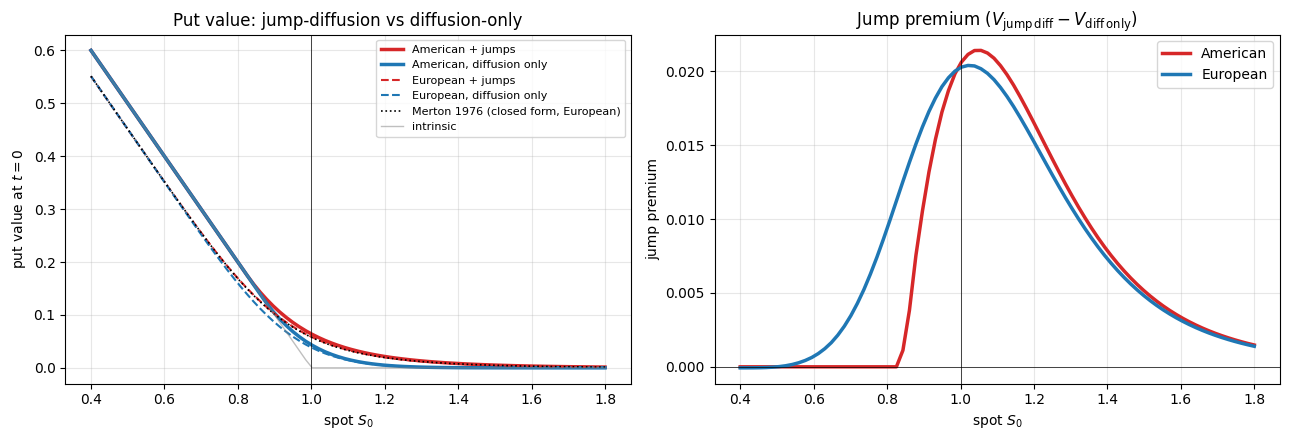

In [7]:
S_grid = np.linspace(0.4, 1.8, 80)
S_t = torch.tensor(S_grid, dtype=torch.float64)

v_am_jd = value_am_jd({"price": S_t}, t=0).numpy()
v_am_d = value_am_d({"price": S_t}, t=0).numpy()
v_eu_jd = value_eu_jd({"price": S_t}, t=0).numpy()
v_eu_d = value_eu_d({"price": S_t}, t=0).numpy()
v_merton = np.array([
    merton_european_put(s, K_strike, r, sigma_diff, T_years, lambda_year, mu_j, sigma_j)
    for s in S_grid
])
v_bs = np.array([
    european_put_bs(s, K_strike, r, sigma_diff, T_years)
    for s in S_grid
])
intrinsic = np.maximum(K_strike - S_grid, 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(S_grid, v_am_jd, lw=2.5, color="C3", label="American + jumps")
ax1.plot(S_grid, v_am_d, lw=2.5, color="C0", label="American, diffusion only")
ax1.plot(S_grid, v_eu_jd, ls="--", lw=1.5, color="C3", label="European + jumps")
ax1.plot(S_grid, v_eu_d, ls="--", lw=1.5, color="C0", label="European, diffusion only")
ax1.plot(S_grid, v_merton, ls=":", lw=1.2, color="black",
         label="Merton 1976 (closed form, European)")
ax1.plot(S_grid, intrinsic, lw=1.0, color="gray", alpha=0.5, label="intrinsic")
ax1.axvline(K_strike, color="black", lw=0.5)
ax1.set_xlabel("spot $S_0$")
ax1.set_ylabel("put value at $t=0$")
ax1.set_title("Put value: jump-diffusion vs diffusion-only")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(alpha=0.3)

# Jump premium: value_with_jumps - value_without_jumps
ax2.plot(S_grid, v_am_jd - v_am_d, lw=2.5, color="C3", label="American")
ax2.plot(S_grid, v_eu_jd - v_eu_d, lw=2.5, color="C0", label="European")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.axvline(K_strike, color="black", lw=0.5)
ax2.set_xlabel("spot $S_0$")
ax2.set_ylabel("jump premium")
ax2.set_title("Jump premium ($V_\\mathrm{jump\\,diff} - V_\\mathrm{diff\\,only}$)")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise boundary with vs without jumps

Downward jumps make holding the option more attractive — there's
more upside to waiting — so the optimal exercise boundary
$S^*(t)$ in the jump-diffusion model sits **below** the boundary in
the pure-diffusion model.

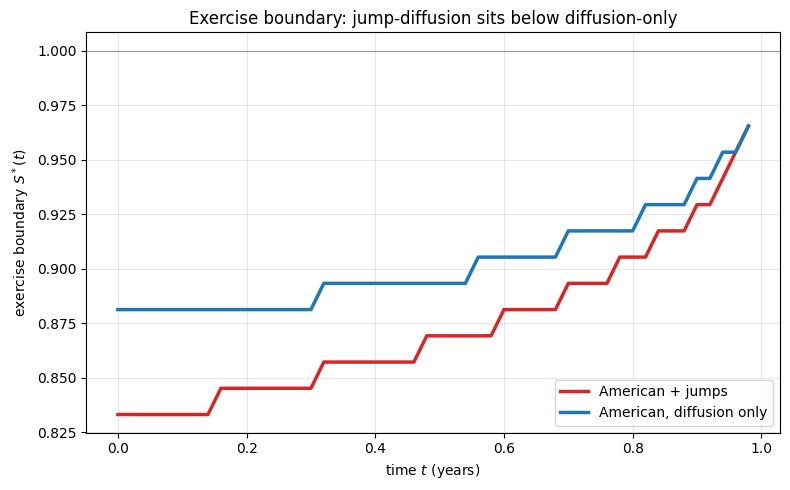

In [8]:
S_search = np.linspace(0.0, K_strike * 1.2, 400)
S_search_t = torch.tensor(S_search, dtype=torch.float64)

def boundary(policy):
    out = []
    for t in range(n_steps):
        a = policy({"price": S_search_t}, t=t)["exercise"].numpy()
        idx = np.where(a == 1)[0]
        out.append(S_search[idx[-1]] if len(idx) > 0 else 0.0)
    return np.array(out)


b_jd = boundary(policy_am_jd)
b_d = boundary(policy_am_d)
t_axis = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_axis, b_jd, lw=2.5, color="C3", label="American + jumps")
ax.plot(t_axis, b_d, lw=2.5, color="C0", label="American, diffusion only")
ax.axhline(K_strike, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("time $t$ (years)")
ax.set_ylabel("exercise boundary $S^*(t)$")
ax.set_title("Exercise boundary: jump-diffusion sits below diffusion-only")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Detailed table

In [9]:
spot_table = [0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2]
print(f"{'S0':>5} {'V_AM_JD':>10} {'V_AM_D':>10} {'V_EU_JD':>10}"
      f" {'V_EU_D':>10} {'AM jump prem':>14}")
print("-" * 65)
for S0 in spot_table:
    s = torch.tensor([S0], dtype=torch.float64)
    v_amj = value_am_jd({"price": s}, t=0).item()
    v_amd = value_am_d({"price": s}, t=0).item()
    v_euj = value_eu_jd({"price": s}, t=0).item()
    v_eud = value_eu_d({"price": s}, t=0).item()
    print(f"{S0:>5.2f} {v_amj:>10.5f} {v_amd:>10.5f} {v_euj:>10.5f}"
          f" {v_eud:>10.5f} {v_amj - v_amd:>14.5f}")

   S0    V_AM_JD     V_AM_D    V_EU_JD     V_EU_D   AM jump prem
-----------------------------------------------------------------
 0.70    0.29999    0.29999    0.25558    0.25217        0.00000
 0.80    0.19999    0.19999    0.16928    0.15992        0.00000
 0.90    0.11437    0.10321    0.10246    0.08599        0.01115
 0.95    0.08571    0.06841    0.07790    0.05892        0.01730
 1.00    0.06420    0.04366    0.05882    0.03856        0.02054
 1.05    0.04826    0.02681    0.04441    0.02415        0.02145
 1.10    0.03654    0.01589    0.03372    0.01453        0.02065
 1.20    0.02151    0.00500    0.01991    0.00468        0.01651
